# Merge CVAT Reviews, Grouped Split, and Two-Stage Datasets

notebook นี้รวมผล review จาก CVAT เป็น reviewed YOLO segmentation dataset ก่อนจัด grouped train/validation/test split โดยเก็บ augmented copies จาก source เดียวกันไว้ใน split เดียว

ผลลัพธ์สุดท้ายคือ `dataset_panel` สำหรับ Stage 1 และ `dataset_defect` สำหรับ Stage 2 พร้อม manifests, validation และกราฟ class distribution


## Setup และค่า split


In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q scikit-learn pandas numpy pyyaml tqdm

from pathlib import Path
from datetime import datetime, timezone
from collections import Counter
import json, math, random, shutil, warnings
import xml.etree.ElementTree as ET
import zipfile

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yaml
from tqdm.auto import tqdm
from sklearn.model_selection import StratifiedGroupKFold

DRIVE_BASE = Path('/content/drive/MyDrive/ai builders/dataset')
CVAT_EXPORTS = DRIVE_BASE / 'cvat_exports'
CVAT_UPLOAD = DRIVE_BASE / 'cvat_upload'
REVIEWED_DATASET = DRIVE_BASE / 'dataset_yolo_v4'
OUTPUT_BASE = REVIEWED_DATASET
WORK_DIR = Path('/content/cvat_work')
UPLOAD_MANIFEST_PATH = CVAT_UPLOAD / 'upload_manifest.csv'
SOURCE_MANIFEST_PATH = REVIEWED_DATASET / 'manifest_kept.csv'
OUTPUT_PANEL = DRIVE_BASE / 'dataset_panel'
OUTPUT_DEFECT = DRIVE_BASE / 'dataset_defect'
SPLIT_MANIFEST_PATH = DRIVE_BASE / 'split_manifest_v2.csv'
SUMMARY_PATH = DRIVE_BASE / 'phase4v2_summary.json'
FIG_DIR = Path('/content/drive/MyDrive/ai builders/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

CATEGORIES = ['A', 'A_partial', 'B', 'C']
SPLITS = ['train', 'val', 'test']
OLD_SPLITS = ['train', 'val', 'test']
RANDOM_SEED = 42
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10
OVERWRITE_OUTPUT = True

EXPORT_FILES = {
    'A': {
        'cvat': CVAT_EXPORTS / 'solar_v4_A_cvat.zip',
        'yolo': CVAT_EXPORTS / 'solar_v4_A_yolo.zip',
    },
    'A_partial': {
        'cvat': CVAT_EXPORTS / 'solar_v4_A_partial_cvat.zip',
        'yolo': CVAT_EXPORTS / 'solar_v4_A_partial_yolo.zip',
    },
    'B': {
        'cvat': CVAT_EXPORTS / 'solar_v4_B_cvat.zip',
        'yolo': CVAT_EXPORTS / 'solar_v4_B_yolo.zip',
    },
    'C': {
        'cvat': CVAT_EXPORTS / 'solar_v4_C_cvat.zip',
        'yolo': CVAT_EXPORTS / 'solar_v4_C_yolo.zip',
    },
}
TAG_NAMES = {'full_panel_view', 'exclude'}
TAG_SOURCE = 'CVAT XML'
SEEDS_TO_TRY = list(range(10))  # fixed for reproducible sampling and training
N_SPLITS = 10

CLASS_NAMES = {0:'panel_clean', 1:'panel_defective', 2:'dust', 3:'bird_drop', 4:'physical_damage', 5:'leaf'}
PANEL_KEEP = {0, 1}
PANEL_REMAP = {0: 0, 1: 0}
PANEL_NAMES = {0: 'panel'}
DEFECT_KEEP = {2, 3, 4, 5}
DEFECT_REMAP = {2: 0, 3: 1, 4: 2, 5: 3}
DEFECT_NAMES = {0: 'dust', 1: 'bird_drop', 2: 'physical_damage', 3: 'leaf'}

warnings.filterwarnings('ignore')
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f'CVAT exports:     {CVAT_EXPORTS}')
print(f'CVAT upload:      {CVAT_UPLOAD}')
print(f'REVIEWED_DATASET: {REVIEWED_DATASET}')
print(f'SOURCE_MANIFEST_PATH: {SOURCE_MANIFEST_PATH}')
print(f'OUTPUT_PANEL: {OUTPUT_PANEL}')
print(f'OUTPUT_DEFECT: {OUTPUT_DEFECT}')


Mounted at /content/drive
CVAT exports:     /content/drive/MyDrive/ai builders/dataset/cvat_exports
CVAT upload:      /content/drive/MyDrive/ai builders/dataset/cvat_upload
REVIEWED_DATASET: /content/drive/MyDrive/ai builders/dataset/dataset_yolo_v4
SOURCE_MANIFEST_PATH: /content/drive/MyDrive/ai builders/dataset/dataset_yolo_v4/manifest_kept.csv
OUTPUT_PANEL: /content/drive/MyDrive/ai builders/dataset/dataset_panel
OUTPUT_DEFECT: /content/drive/MyDrive/ai builders/dataset/dataset_defect


## ตรวจ CVAT exports และ source images


In [2]:
def file_size_mb(path):
    return path.stat().st_size / 1_000_000 if path.exists() else 0

print('Checking CVAT export files')
missing = []
for category, formats in EXPORT_FILES.items():
    for fmt, path in formats.items():
        exists = path.exists()
        status = 'OK' if exists else 'MISSING'
        print(f'  {status:<8} {category:<10} {fmt:<5} {path.name:<34} {file_size_mb(path):>8.1f} MB')
        if not exists:
            missing.append(str(path))

print('\nChecking source image folders')
for category in CATEGORIES:
    img_dir = CVAT_UPLOAD / category / 'images'
    n_images = len(list(img_dir.glob('*.jpg'))) if img_dir.exists() else 0
    status = 'OK' if img_dir.exists() and n_images > 0 else 'MISSING/EMPTY'
    print(f'  {status:<13} {category:<10} {img_dir} ({n_images:,} jpg files)')
    if not img_dir.exists() or n_images == 0:
        missing.append(str(img_dir))

if missing:
    raise FileNotFoundError('Missing required CVAT merge inputs:\n' + '\n'.join(missing))
print('\nAll required zip files and source image folders found.')

Checking CVAT export files
  OK       A          cvat  solar_v4_A_cvat.zip                     5.1 MB
  OK       A          yolo  solar_v4_A_yolo.zip                     4.3 MB
  OK       A_partial  cvat  solar_v4_A_partial_cvat.zip             0.4 MB
  OK       A_partial  yolo  solar_v4_A_partial_yolo.zip             0.3 MB
  OK       B          cvat  solar_v4_B_cvat.zip                     1.7 MB
  OK       B          yolo  solar_v4_B_yolo.zip                     1.5 MB
  OK       C          cvat  solar_v4_C_cvat.zip                     2.0 MB
  OK       C          yolo  solar_v4_C_yolo.zip                     2.0 MB

Checking source image folders
  OK            A          /content/drive/MyDrive/ai builders/dataset/cvat_upload/A/images (1,310 jpg files)
  OK            A_partial  /content/drive/MyDrive/ai builders/dataset/cvat_upload/A_partial/images (53 jpg files)
  OK            B          /content/drive/MyDrive/ai builders/dataset/cvat_upload/B/images (584 jpg files)
  OK        

## แตกไฟล์ CVAT exports


In [3]:
def reset_dir(path):
    path = Path(path)
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

reset_dir(WORK_DIR)

if OUTPUT_BASE.exists():
    if OVERWRITE_OUTPUT:
        shutil.rmtree(OUTPUT_BASE)
        print(f'Removed old output folder: {OUTPUT_BASE}')
    else:
        raise RuntimeError(f'Output folder already exists and OVERWRITE_OUTPUT=False: {OUTPUT_BASE}')

for split in SPLITS:
    (OUTPUT_BASE / 'images' / split).mkdir(parents=True, exist_ok=True)
    (OUTPUT_BASE / 'labels' / split).mkdir(parents=True, exist_ok=True)

print('Extracting CVAT exports')
extract_stats = []
for category, formats in EXPORT_FILES.items():
    for fmt, zip_path in formats.items():
        extract_to = WORK_DIR / f'{category}_{fmt}'
        extract_to.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(extract_to)
        n_files = sum(1 for p in extract_to.rglob('*') if p.is_file())
        extract_stats.append({'category': category, 'format': fmt, 'files': n_files, 'path': str(extract_to)})
        print(f'  {category:<10} {fmt:<5} -> {n_files:>6,} files at {extract_to}')
print('\nExtraction complete.')

Removed old output folder: /content/drive/MyDrive/ai builders/dataset/dataset_yolo_v4
Extracting CVAT exports
  A          cvat  ->      1 files at /content/cvat_work/A_cvat
  A          yolo  ->  1,312 files at /content/cvat_work/A_yolo
  A_partial  cvat  ->      1 files at /content/cvat_work/A_partial_cvat
  A_partial  yolo  ->     55 files at /content/cvat_work/A_partial_yolo
  B          cvat  ->      1 files at /content/cvat_work/B_cvat
  B          yolo  ->    586 files at /content/cvat_work/B_yolo
  C          cvat  ->      1 files at /content/cvat_work/C_cvat
  C          yolo  ->    764 files at /content/cvat_work/C_yolo

Extraction complete.


## เชื่อม safe filename กับ image ID


In [4]:
def filename_to_image_id(filename):
    stem = Path(str(filename)).name
    if stem.lower().endswith('.jpg'):
        stem = stem[:-4]
    return stem.replace('__', '::')

upload_manifest = None
filename_to_image_id_map = {}
category_filename_to_image_id = {}

if UPLOAD_MANIFEST_PATH.exists():
    upload_manifest = pd.read_csv(UPLOAD_MANIFEST_PATH)
    required = {'safe_filename', 'image_id'}
    missing_cols = required - set(upload_manifest.columns)
    if missing_cols:
        raise ValueError(f'upload_manifest.csv missing columns: {sorted(missing_cols)}')
    upload_manifest['safe_filename'] = upload_manifest['safe_filename'].astype(str)
    upload_manifest['image_id'] = upload_manifest['image_id'].astype(str)
    filename_to_image_id_map = dict(zip(upload_manifest['safe_filename'], upload_manifest['image_id']))
    if 'final_category' in upload_manifest.columns:
        for _, row in upload_manifest.iterrows():
            category_filename_to_image_id[(str(row['final_category']), str(row['safe_filename']))] = str(row['image_id'])
    print(f'Loaded upload manifest: {UPLOAD_MANIFEST_PATH} ({len(upload_manifest):,} rows)')
else:
    print(f'No upload manifest found at {UPLOAD_MANIFEST_PATH}; using filename fallback mapping.')

available_images = {}
unsafe_source_files = []
for category in CATEGORIES:
    img_dir = CVAT_UPLOAD / category / 'images'
    files = sorted(p.name for p in img_dir.glob('*.jpg'))
    available_images[category] = set(files)
    unsafe = [f for f in files if '::' in f]
    unsafe_source_files.extend((category, f) for f in unsafe)
    print(f'  {category:<10} source images: {len(files):,}')

if unsafe_source_files:
    raise ValueError(f'Source images still contain unsafe "::" filenames. Sample: {unsafe_source_files[:10]}')
print('Source image index ready.')

Loaded upload manifest: /content/drive/MyDrive/ai builders/dataset/cvat_upload/upload_manifest.csv (2,709 rows)
  A          source images: 1,310
  A_partial  source images: 53
  B          source images: 584
  C          source images: 762
Source image index ready.


## อ่าน image-level tags จาก CVAT XML

ใช้ XML สำหรับ `full_panel_view` และ `exclude` เพราะ YOLO export เก็บเฉพาะ segmentation polygons


In [5]:
def normalize_filename(value):
    text = str(value).replace('\\', '/')
    return Path(text).name


def normalize_name(value):
    return str(value).strip().lower().replace(' ', '_').replace('-', '_')


def find_cvat_xml(category):
    root = WORK_DIR / f'{category}_cvat'
    xml_files = sorted(p for p in root.rglob('*.xml') if '__MACOSX' not in {part.upper() for part in p.parts})
    if not xml_files:
        raise FileNotFoundError(f'No CVAT XML file found under {root}')

    def score(path):
        name = path.name.lower()
        parent = str(path.parent).lower()
        value = 0
        if name == 'annotations.xml':
            value += 10
        if 'annotation' in name:
            value += 5
        if 'default' in name:
            value += 3
        if 'annotations' in parent:
            value += 2
        return value

    return max(xml_files, key=score)


def parse_image_tag_elements(image_el):
    tags = {'full_panel_view': False, 'exclude': False}
    for tag_el in image_el.findall('tag'):
        label = normalize_name(tag_el.attrib.get('label', ''))
        if label in TAG_NAMES:
            tags[label] = True

        # Defensive fallback: some CVAT exports can carry values in nested attributes.
        for attr_el in tag_el.findall('attribute'):
            attr_name = normalize_name(attr_el.attrib.get('name', ''))
            attr_text = (attr_el.text or '').strip().lower()
            if attr_name in TAG_NAMES and attr_text in {'1', 'true', 'yes', 'y'}:
                tags[attr_name] = True
    return tags


def parse_cvat_xml_attributes(category):
    xml_path = find_cvat_xml(category)
    tree = ET.parse(xml_path)
    root = tree.getroot()
    attributes = {}

    for image_el in root.findall('.//image'):
        raw_name = image_el.attrib.get('name')
        if not raw_name:
            continue
        filename = normalize_filename(raw_name)
        image_tags = parse_image_tag_elements(image_el)
        attributes[filename] = image_tags

    if not attributes:
        raise ValueError(f'No <image> entries found in CVAT XML: {xml_path}')

    n_full = sum(1 for row in attributes.values() if row['full_panel_view'])
    n_exclude = sum(1 for row in attributes.values() if row['exclude'])
    xml_only = sorted(set(attributes) - available_images[category])

    print(f'  {category:<10} {xml_path.relative_to(WORK_DIR)}')
    print(f'    XML images: {len(attributes):,}, full_panel_view: {n_full:,}, exclude: {n_exclude:,}')
    if xml_only:
        print(f'    warning: {len(xml_only):,} XML filenames not found in cvat_upload/{category}/images. Sample: {xml_only[:5]}')
    return attributes

print('Parsing CVAT XML image-level tags')
all_attributes = {category: parse_cvat_xml_attributes(category) for category in CATEGORIES}

xml_tag_stats = {
    category: {
        'xml_images': int(len(attrs)),
        'full_panel_view': int(sum(1 for row in attrs.values() if row['full_panel_view'])),
        'exclude': int(sum(1 for row in attrs.values() if row['exclude'])),
    }
    for category, attrs in all_attributes.items()
}
print('\nCVAT XML tag summary:')
print(pd.DataFrame(xml_tag_stats).T)

Parsing CVAT XML image-level tags
  A          A_cvat/annotations.xml
    XML images: 1,310, full_panel_view: 0, exclude: 98
  A_partial  A_partial_cvat/annotations.xml
    XML images: 53, full_panel_view: 0, exclude: 0
  B          B_cvat/annotations.xml
    XML images: 584, full_panel_view: 0, exclude: 281
  C          C_cvat/annotations.xml
    XML images: 762, full_panel_view: 0, exclude: 1

CVAT XML tag summary:
           xml_images  full_panel_view  exclude
A                1310                0       98
A_partial          53                0        0
B                 584                0      281
C                 762                0        1


## อ่าน segmentation labels จาก CVAT YOLO export


In [6]:
META_TXT_NAMES = {
    'classes.txt', 'obj.names', 'obj.data', 'train.txt', 'valid.txt', 'val.txt',
    'test.txt', 'data.txt', 'data.yaml', 'dataset.yaml'
}


def is_probable_label_file(path):
    if path.name.lower() in META_TXT_NAMES:
        return False
    parts = {part.lower() for part in path.parts}
    if '__macosx' in parts:
        return False
    return path.suffix.lower() == '.txt'


def infer_image_filename_from_label(txt_path, category, attrs):
    candidate = f'{txt_path.stem}.jpg'
    if candidate in available_images[category] or candidate in attrs:
        return candidate
    stem_lower = txt_path.stem.lower()
    candidates = [name for name in available_images[category] if Path(name).stem.lower() == stem_lower]
    if len(candidates) == 1:
        return candidates[0]
    attr_candidates = [name for name in attrs if Path(name).stem.lower() == stem_lower]
    if len(attr_candidates) == 1:
        return attr_candidates[0]
    return candidate


def parse_yolo_labels_raw(category):
    root = WORK_DIR / f'{category}_yolo'
    label_files = sorted(p for p in root.rglob('*.txt') if is_probable_label_file(p))
    labels = {}
    bad_lines = []
    raw_class_ids = []
    attrs = all_attributes.get(category, {})

    for txt_path in label_files:
        filename = infer_image_filename_from_label(txt_path, category, attrs)
        polygons = []
        with open(txt_path, 'r', encoding='utf-8') as f:
            for line_no, line in enumerate(f, start=1):
                text = line.strip()
                if not text:
                    continue
                parts = text.split()
                if len(parts) < 7:
                    bad_lines.append((category, str(txt_path), line_no, 'too few values'))
                    continue
                try:
                    raw_cls = int(float(parts[0]))
                    coords = [float(x) for x in parts[1:]]
                except ValueError:
                    bad_lines.append((category, str(txt_path), line_no, 'parse error'))
                    continue
                if len(coords) % 2 != 0:
                    bad_lines.append((category, str(txt_path), line_no, 'odd coordinate count'))
                    continue
                if len(coords) < 6:
                    bad_lines.append((category, str(txt_path), line_no, 'polygon has fewer than 3 points'))
                    continue
                if any((not math.isfinite(c)) or c < 0 or c > 1 for c in coords):
                    bad_lines.append((category, str(txt_path), line_no, 'coordinate outside [0,1]'))
                    continue
                polygons.append((raw_cls, coords))
                raw_class_ids.append(raw_cls)
        labels[filename] = polygons

    n_polygons = sum(len(v) for v in labels.values())
    print(f'  {category:<10} label files: {len(label_files):,}, images with txt: {len(labels):,}, polygons: {n_polygons:,}, bad lines: {len(bad_lines):,}')
    return labels, raw_class_ids, bad_lines

print('Parsing YOLO labels')
raw_labels = {}
all_raw_class_ids = []
all_bad_lines = []
for category in CATEGORIES:
    labels, ids, bad = parse_yolo_labels_raw(category)
    raw_labels[category] = labels
    all_raw_class_ids.extend(ids)
    all_bad_lines.extend(bad)

if all_bad_lines:
    bad_df = pd.DataFrame(all_bad_lines, columns=['category', 'path', 'line_no', 'reason'])
    bad_path = OUTPUT_BASE / 'bad_yolo_lines.csv'
    bad_df.to_csv(bad_path, index=False)
    print(f'Warning: skipped {len(bad_df):,} malformed label lines. Saved: {bad_path}')

if not all_raw_class_ids:
    raise ValueError('No YOLO polygons found in any CVAT export.')

raw_unique = sorted(set(all_raw_class_ids))
raw_min = min(raw_unique)
raw_max = max(raw_unique)
if raw_min >= 0 and raw_max <= 5 and 0 in raw_unique:
    CLASS_ID_OFFSET = 0
    class_id_mode = 'already_0_indexed'
elif raw_min >= 1 and raw_max <= 6:
    CLASS_ID_OFFSET = 1
    class_id_mode = 'cvat_1_indexed_subtract_1'
elif raw_min >= 0 and raw_max <= 5:
    CLASS_ID_OFFSET = 0
    class_id_mode = 'ambiguous_default_0_indexed'
else:
    raise ValueError(f'Unexpected raw class IDs from CVAT YOLO export: {raw_unique}')

print('\nClass ID detection')
print(f'  raw IDs: {raw_unique}')
print(f'  mode:    {class_id_mode}')
print(f'  offset:  {CLASS_ID_OFFSET}')

all_labels = {}
for category, labels in raw_labels.items():
    adjusted = {}
    for filename, polygons in labels.items():
        adjusted_polygons = []
        for raw_cls, coords in polygons:
            cls_id = raw_cls - CLASS_ID_OFFSET
            if cls_id not in CLASS_NAMES:
                raise ValueError(f'Adjusted class id out of range for {category}/{filename}: raw={raw_cls}, adjusted={cls_id}')
            adjusted_polygons.append((cls_id, coords))
        adjusted[filename] = adjusted_polygons
    all_labels[category] = adjusted
print('YOLO labels normalized to 0-indexed class IDs.')

Parsing YOLO labels
  A          label files: 1,310, images with txt: 1,310, polygons: 20,587, bad lines: 0
  A_partial  label files: 53, images with txt: 53, polygons: 1,308, bad lines: 0
  B          label files: 584, images with txt: 584, polygons: 6,713, bad lines: 0
  C          label files: 762, images with txt: 762, polygons: 7,027, bad lines: 0

Class ID detection
  raw IDs: [0, 1, 2, 3, 4, 5]
  mode:    already_0_indexed
  offset:  0
YOLO labels normalized to 0-indexed class IDs.


## สร้าง reviewed manifest


In [7]:
def image_id_for(category, filename):
    if (category, filename) in category_filename_to_image_id:
        return category_filename_to_image_id[(category, filename)]
    if filename in filename_to_image_id_map:
        return filename_to_image_id_map[filename]
    return filename_to_image_id(filename)


def class_counts_for(polygons):
    return Counter(cls_id for cls_id, _coords in polygons)


def dominant_class_from_counts(counts):
    if not counts:
        return 'none'
    cls_id, _count = sorted(counts.items(), key=lambda item: (-item[1], item[0]))[0]
    return CLASS_NAMES[int(cls_id)]

rows = []
for category in CATEGORIES:
    attrs = all_attributes.get(category, {})
    labels = all_labels.get(category, {})
    filenames = sorted(set(attrs.keys()) | set(labels.keys()))
    for filename in filenames:
        polygons = labels.get(filename, [])
        counts = class_counts_for(polygons)
        attr = attrs.get(filename, {'full_panel_view': False, 'exclude': False})
        row = {
            'filename': filename,
            'safe_filename': filename,
            'image_id': image_id_for(category, filename),
            'category': category,
            'full_panel_view': bool(attr.get('full_panel_view', False)),
            'exclude': bool(attr.get('exclude', False)),
            'n_polygons': int(len(polygons)),
            'class_counts': json.dumps({CLASS_NAMES[int(k)]: int(v) for k, v in sorted(counts.items())}, sort_keys=True),
            'dominant_class': dominant_class_from_counts(counts),
            'xml_record_exists': filename in attrs,
            'source_image_exists': filename in available_images[category],
            'unsafe_filename': '::' in filename,
        }
        for cls_id, cls_name in CLASS_NAMES.items():
            row[f'count_{cls_name}'] = int(counts.get(cls_id, 0))
        row['will_be_kept'] = (not row['exclude']) and row['n_polygons'] > 0
        rows.append(row)

manifest = pd.DataFrame(rows)
if manifest.empty:
    raise ValueError('Unified manifest is empty. Check CVAT exports.')
kept = manifest[manifest['will_be_kept']].copy().reset_index(drop=True)

print('Unified manifest')
print(f'Total rows:      {len(manifest):,}')
print(f'Kept rows:       {len(kept):,}')
print(f'Excluded tags:   {int(manifest["exclude"].sum()):,}')
print(f'Empty labels:    {int((manifest["n_polygons"] == 0).sum()):,}')
print(f'Full panel tags: {int(manifest["full_panel_view"].sum()):,}')
print('\nRows by category:')
print(manifest.groupby('category').size().reindex(CATEGORIES).fillna(0).astype(int))
print('\nKept by category:')
print(kept.groupby('category').size().reindex(CATEGORIES).fillna(0).astype(int))
print('\nFiltered out by category:')
print(manifest[~manifest['will_be_kept']].groupby('category').size().reindex(CATEGORIES).fillna(0).astype(int))

Unified manifest
Total rows:      2,709
Kept rows:       2,329
Excluded tags:   380
Empty labels:    0
Full panel tags: 0

Rows by category:
category
A            1310
A_partial      53
B             584
C             762
dtype: int64

Kept by category:
category
A            1212
A_partial      53
B             303
C             761
dtype: int64

Filtered out by category:
category
A             98
A_partial      0
B            281
C              1
dtype: int64


## ตรวจ reviewed annotations ก่อน export


In [8]:
def summarize_class_distribution(df):
    counts = Counter()
    for _, row in df.iterrows():
        for cls_id, cls_name in CLASS_NAMES.items():
            counts[cls_id] += int(row.get(f'count_{cls_name}', 0))
    return counts

pre_export_errors = []

print('XML/Yolo/source filename consistency')
for category in CATEGORIES:
    xml_files = set(all_attributes.get(category, {}))
    yolo_files = set(all_labels.get(category, {}))
    source_files = available_images.get(category, set())
    xml_missing_source = sorted(xml_files - source_files)
    yolo_missing_xml = sorted(yolo_files - xml_files)
    xml_missing_yolo = sorted(xml_files - yolo_files)
    print(f'  {category:<10} xml={len(xml_files):,} yolo={len(yolo_files):,} source={len(source_files):,}')
    if xml_missing_source:
        print(f'    warning: XML-only vs source: {len(xml_missing_source):,}. Sample: {xml_missing_source[:5]}')
    if yolo_missing_xml:
        print(f'    error: YOLO filenames missing from XML: {len(yolo_missing_xml):,}. Sample: {yolo_missing_xml[:5]}')
        pre_export_errors.append(f'{category}: {len(yolo_missing_xml):,} YOLO filenames missing from CVAT XML tag export')
    if xml_missing_yolo:
        print(f'    note: XML filenames without YOLO labels: {len(xml_missing_yolo):,}. These will be dropped if n_polygons=0 unless only metadata rows.')

unsafe = manifest[manifest['unsafe_filename']]
if len(unsafe):
    pre_export_errors.append(f'{len(unsafe):,} manifest filenames contain unsafe "::"')
missing_xml_records = kept[~kept['xml_record_exists']]
if len(missing_xml_records):
    pre_export_errors.append(f'{len(missing_xml_records):,} kept images are missing from CVAT XML tag export')
missing_sources = kept[~kept['source_image_exists']]
if len(missing_sources):
    pre_export_errors.append(f'{len(missing_sources):,} kept images are missing from cvat_upload source folders')
kept_dupes = kept[kept.duplicated('filename', keep=False)]
if len(kept_dupes):
    pre_export_errors.append(f'{kept_dupes["filename"].nunique():,} kept filenames are duplicated across categories')
if (kept['n_polygons'] <= 0).any():
    pre_export_errors.append('kept manifest contains images with zero polygons')

for category, labels in all_labels.items():
    for filename, polygons in labels.items():
        for cls_id, coords in polygons:
            if cls_id not in CLASS_NAMES:
                pre_export_errors.append(f'invalid class id {cls_id} in {category}/{filename}')
                break
            if len(coords) < 6 or len(coords) % 2 != 0:
                pre_export_errors.append(f'invalid polygon coordinate count in {category}/{filename}')
                break
            if any(c < 0 or c > 1 or not math.isfinite(c) for c in coords):
                pre_export_errors.append(f'coords outside [0,1] in {category}/{filename}')
                break

if pre_export_errors:
    print('Pre-export validation failed:')
    for err in pre_export_errors[:30]:
        print(f'  - {err}')
    if len(pre_export_errors) > 30:
        print(f'  ... and {len(pre_export_errors) - 30} more')
    raise ValueError('Fix the pre-export validation errors before exporting.')
print('Pre-export validation passed.')

print('\nClass distribution after filtering')
class_dist = summarize_class_distribution(kept)
total_polygons = sum(class_dist.values())
for cls_id, cls_name in CLASS_NAMES.items():
    count = class_dist.get(cls_id, 0)
    pct = count / total_polygons * 100 if total_polygons else 0
    print(f'  {cls_id} {cls_name:<18} {count:>8,} ({pct:>6.2f}%)')
print(f'  TOTAL                {total_polygons:>8,}')
positive_counts = [v for v in class_dist.values() if v > 0]
imbalance_ratio = max(positive_counts) / min(positive_counts) if positive_counts else 0.0
print(f'\nImbalance ratio (max/min nonzero): {imbalance_ratio:.2f}')

XML/Yolo/source filename consistency
  A          xml=1,310 yolo=1,310 source=1,310
  A_partial  xml=53 yolo=53 source=53
  B          xml=584 yolo=584 source=584
  C          xml=762 yolo=762 source=762
Pre-export validation passed.

Class distribution after filtering
  0 panel_clean           7,087 ( 23.69%)
  1 panel_defective       6,497 ( 21.72%)
  2 dust                  4,867 ( 16.27%)
  3 bird_drop             6,120 ( 20.46%)
  4 physical_damage       2,504 (  8.37%)
  5 leaf                  2,843 (  9.50%)
  TOTAL                  29,918

Imbalance ratio (max/min nonzero): 2.83


## สร้าง temporary split สำหรับ reviewed dataset


In [9]:
def deterministic_shuffle(df, seed):
    return df.sample(frac=1, random_state=seed).reset_index(drop=True)


def split_counts_for_group(n):
    if n <= 0:
        return {'train': 0, 'val': 0, 'test': 0}
    n_train = int(math.floor(n * TRAIN_RATIO))
    n_val = int(math.floor(n * VAL_RATIO))
    n_test = n - n_train - n_val
    if n >= 3 and n_val == 0:
        n_val = 1
        n_train = max(1, n_train - 1)
    if n >= 3 and n_test == 0:
        n_test = 1
        n_train = max(1, n_train - 1)
    if n == 2 and n_train == 0:
        n_train = 1
        n_test = 1
    if n_train + n_val + n_test != n:
        n_train = n - n_val - n_test
    return {'train': n_train, 'val': n_val, 'test': n_test}


def stratified_split(df):
    working = df.copy().reset_index(drop=True)
    working['stratum'] = working['category'].astype(str) + '__' + working['dominant_class'].astype(str)
    split_frames = {split: [] for split in SPLITS}
    for stratum, group in sorted(working.groupby('stratum'), key=lambda item: (-len(item[1]), item[0])):
        group = deterministic_shuffle(group, RANDOM_SEED)
        counts = split_counts_for_group(len(group))
        start = 0
        for split in SPLITS:
            end = start + counts[split]
            if end > start:
                part = group.iloc[start:end].copy()
                part['split'] = split
                split_frames[split].append(part)
            start = end
    result = {}
    for split in SPLITS:
        if split_frames[split]:
            result[split] = deterministic_shuffle(pd.concat(split_frames[split], ignore_index=True), RANDOM_SEED)
        else:
            result[split] = working.iloc[0:0].copy()
            result[split]['split'] = split
    return result

splits = stratified_split(kept)
kept_with_split = pd.concat([splits[split] for split in SPLITS], ignore_index=True)
if len(kept_with_split) != len(kept):
    raise AssertionError(f'Split total mismatch: {len(kept_with_split):,} vs kept {len(kept):,}')

manifest_with_split = manifest.copy()
manifest_with_split['split'] = ''
split_lookup = dict(zip(zip(kept_with_split['category'], kept_with_split['filename']), kept_with_split['split']))
manifest_with_split['split'] = [split_lookup.get((row.category, row.filename), '') for row in manifest_with_split.itertuples()]

print('Split sizes')
for split in SPLITS:
    split_df = splits[split]
    print(f'\n{split}: {len(split_df):,} images')
    print('  by category:')
    print(split_df.groupby('category').size().reindex(CATEGORIES).fillna(0).astype(int).to_string())
    print('  by dominant_class:')
    print(split_df.groupby('dominant_class').size().sort_index().to_string())
print(f'\nTotal split rows = kept rows = {len(kept):,}')

Split sizes

train: 1,852 images
  by category:
category
A            967
A_partial     41
B            239
C            605
  by dominant_class:
dominant_class
bird_drop          245
dust                80
leaf               358
panel_clean        502
panel_defective    336
physical_damage    331

val: 227 images
  by category:
category
A            119
A_partial      4
B             29
C             75
  by dominant_class:
dominant_class
bird_drop          30
dust               10
leaf               44
panel_clean        62
panel_defective    40
physical_damage    41

test: 250 images
  by category:
category
A            126
A_partial      8
B             35
C             81
  by dominant_class:
dominant_class
bird_drop          34
dust               11
leaf               46
panel_clean        67
panel_defective    47
physical_damage    45

Total split rows = kept rows = 2,329


## Export reviewed YOLO dataset


In [10]:
def source_image_path(category, filename):
    return CVAT_UPLOAD / category / 'images' / filename


def write_yolo_label(polygons, output_path):
    lines = []
    for cls_id, coords in polygons:
        coord_text = ' '.join(f'{float(c):.6f}' for c in coords)
        lines.append(f'{int(cls_id)} {coord_text}')
    output_path.write_text('\n'.join(lines) + ('\n' if lines else ''), encoding='utf-8')


def export_split(split, split_df):
    img_out = OUTPUT_BASE / 'images' / split
    lbl_out = OUTPUT_BASE / 'labels' / split
    stats = {'images': 0, 'labels': 0, 'missing_source': 0, 'empty_labels': 0}
    for row in tqdm(split_df.itertuples(index=False), total=len(split_df), desc=f'export {split}'):
        filename = row.filename
        category = row.category
        src = source_image_path(category, filename)
        dst_img = img_out / filename
        dst_lbl = lbl_out / f'{Path(filename).stem}.txt'
        if not src.exists():
            stats['missing_source'] += 1
            continue
        shutil.copy2(src, dst_img)
        polygons = all_labels[category].get(filename, [])
        if not polygons:
            stats['empty_labels'] += 1
        write_yolo_label(polygons, dst_lbl)
        stats['images'] += 1
        stats['labels'] += 1
    return stats

print('Exporting YOLO dataset')
export_stats = {}
for split in SPLITS:
    export_stats[split] = export_split(split, splits[split])
    print(f'  {split:<5} {export_stats[split]}')
if any(stats['missing_source'] for stats in export_stats.values()):
    raise FileNotFoundError(f'Missing source images during export: {export_stats}')
if any(stats['empty_labels'] for stats in export_stats.values()):
    raise ValueError(f'Kept images produced empty labels during export: {export_stats}')

manifest_full_path = OUTPUT_BASE / 'manifest_full.csv'
manifest_kept_path = OUTPUT_BASE / 'manifest_kept.csv'
manifest_path = OUTPUT_BASE / 'manifest.csv'
manifest_with_split.to_csv(manifest_full_path, index=False)
kept_with_split.to_csv(manifest_kept_path, index=False)
kept_with_split.to_csv(manifest_path, index=False)
print('\nSaved manifests:')
print(f'  {manifest_full_path}')
print(f'  {manifest_kept_path}')
print(f'  {manifest_path}')

Exporting YOLO dataset


export train:   0%|          | 0/1852 [00:00<?, ?it/s]

  train {'images': 1852, 'labels': 1852, 'missing_source': 0, 'empty_labels': 0}


export val:   0%|          | 0/227 [00:00<?, ?it/s]

  val   {'images': 227, 'labels': 227, 'missing_source': 0, 'empty_labels': 0}


export test:   0%|          | 0/250 [00:00<?, ?it/s]

  test  {'images': 250, 'labels': 250, 'missing_source': 0, 'empty_labels': 0}

Saved manifests:
  /content/drive/MyDrive/ai builders/dataset/dataset_yolo_v4/manifest_full.csv
  /content/drive/MyDrive/ai builders/dataset/dataset_yolo_v4/manifest_kept.csv
  /content/drive/MyDrive/ai builders/dataset/dataset_yolo_v4/manifest.csv


## เขียน data.yaml ของ reviewed dataset


In [11]:
data_yaml = {
    'path': str(OUTPUT_BASE),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': len(CLASS_NAMES),
    'names': CLASS_NAMES,
}

data_yaml_path = OUTPUT_BASE / 'data.yaml'
with open(data_yaml_path, 'w', encoding='utf-8') as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)
print(f'Saved: {data_yaml_path}')
print(data_yaml_path.read_text(encoding='utf-8'))

Saved: /content/drive/MyDrive/ai builders/dataset/dataset_yolo_v4/data.yaml
path: /content/drive/MyDrive/ai builders/dataset/dataset_yolo_v4
train: images/train
val: images/val
test: images/test
nc: 6
names:
  0: panel_clean
  1: panel_defective
  2: dust
  3: bird_drop
  4: physical_damage
  5: leaf



## ตรวจ reviewed dataset ที่ export แล้ว


In [12]:
def validate_label_file(path):
    errors = []
    text = path.read_text(encoding='utf-8').strip()
    if not text:
        errors.append(f'{path}: empty label file')
        return errors
    for line_no, line in enumerate(text.splitlines(), start=1):
        parts = line.split()
        if len(parts) < 7:
            errors.append(f'{path}:{line_no}: too few values')
            continue
        try:
            cls_id = int(float(parts[0]))
            coords = [float(x) for x in parts[1:]]
        except ValueError:
            errors.append(f'{path}:{line_no}: parse error')
            continue
        if cls_id not in CLASS_NAMES:
            errors.append(f'{path}:{line_no}: invalid class id {cls_id}')
        if len(coords) < 6 or len(coords) % 2 != 0:
            errors.append(f'{path}:{line_no}: invalid coordinate count {len(coords)}')
        if any(c < 0 or c > 1 or not math.isfinite(c) for c in coords):
            errors.append(f'{path}:{line_no}: coordinate outside [0,1]')
    return errors

validation_errors = []
validation_counts = {}
for split in SPLITS:
    img_dir = OUTPUT_BASE / 'images' / split
    lbl_dir = OUTPUT_BASE / 'labels' / split
    images = sorted(img_dir.glob('*.jpg'))
    labels = sorted(lbl_dir.glob('*.txt'))
    img_stems = {p.stem for p in images}
    lbl_stems = {p.stem for p in labels}
    missing_labels = sorted(img_stems - lbl_stems)
    missing_images = sorted(lbl_stems - img_stems)
    if missing_labels:
        validation_errors.append(f'{split}: {len(missing_labels):,} images without labels')
    if missing_images:
        validation_errors.append(f'{split}: {len(missing_images):,} labels without images')
    for label_path in labels:
        validation_errors.extend(validate_label_file(label_path))
    expected = len(splits[split])
    if len(images) != expected or len(labels) != expected:
        validation_errors.append(f'{split}: expected {expected:,}, got {len(images):,} images and {len(labels):,} labels')
    validation_counts[split] = {'images': len(images), 'labels': len(labels), 'expected': expected}
    print(f'  {split:<5} images={len(images):,} labels={len(labels):,} expected={expected:,}')

if len(kept_with_split) != sum(v['images'] for v in validation_counts.values()):
    validation_errors.append('exported image total does not match kept manifest total')
if validation_errors:
    print('\nValidation errors:')
    for err in validation_errors[:50]:
        print(f'  - {err}')
    if len(validation_errors) > 50:
        print(f'  ... and {len(validation_errors) - 50} more')
    raise ValueError('Final validation failed.')
print('\nFinal validation passed.')

  train images=1,852 labels=1,852 expected=1,852
  val   images=227 labels=227 expected=227
  test  images=250 labels=250 expected=250

Final validation passed.


## โหลด reviewed manifest และหาไฟล์ต้นฉบับ


In [13]:
def require_file(path, hint=''):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'Missing required file: {path}\n{hint}')
    return path

def require_dir(path, hint=''):
    path = Path(path)
    if not path.exists() or not path.is_dir():
        raise FileNotFoundError(f'Missing required directory: {path}\n{hint}')
    return path

require_file(
    SOURCE_MANIFEST_PATH,
    'Run the CVAT merge and reviewed-dataset validation cells above first.',
)
require_dir(REVIEWED_DATASET / 'images')
require_dir(REVIEWED_DATASET / 'labels')

manifest = pd.read_csv(SOURCE_MANIFEST_PATH)
required_cols = {'filename', 'category'}
missing_cols = required_cols - set(manifest.columns)
if missing_cols:
    raise ValueError(f'manifest_kept.csv missing required columns: {sorted(missing_cols)}')
manifest['filename'] = manifest['filename'].astype(str)
manifest['category'] = manifest['category'].astype(str)

image_index, label_index = {}, {}
image_duplicates, label_duplicates = [], []
for split in OLD_SPLITS:
    img_dir = REVIEWED_DATASET / 'images' / split
    lbl_dir = REVIEWED_DATASET / 'labels' / split
    require_dir(img_dir)
    require_dir(lbl_dir)
    for path in sorted(img_dir.glob('*.jpg')):
        if path.name in image_index:
            image_duplicates.append(path.name)
        image_index[path.name] = path
    for path in sorted(lbl_dir.glob('*.txt')):
        if path.stem in label_index:
            label_duplicates.append(path.stem)
        label_index[path.stem] = path

if image_duplicates:
    raise ValueError(f'Duplicate image filenames across old splits: {image_duplicates[:10]}')
if label_duplicates:
    raise ValueError(f'Duplicate label stems across old splits: {label_duplicates[:10]}')

missing_images = sorted(set(manifest['filename']) - set(image_index))
missing_labels = sorted(set(Path(f).stem for f in manifest['filename']) - set(label_index))
if missing_images:
    raise FileNotFoundError(f'{len(missing_images):,} manifest images missing from dataset_yolo_v4/images. Sample: {missing_images[:10]}')
if missing_labels:
    raise FileNotFoundError(f'{len(missing_labels):,} manifest labels missing from dataset_yolo_v4/labels. Sample: {missing_labels[:10]}')

print(f'Kept manifest rows: {len(manifest):,}')
print(f'Indexed reviewed images:  {len(image_index):,}')
print(f'Indexed reviewed labels:  {len(label_index):,}')


Kept manifest rows: 2,329
Indexed reviewed images:  2,329
Indexed reviewed labels:  2,329


## Parse polygon labels


In [14]:
def parse_label_file(path):
    """Parse one input into the normalized representation used below."""
    polygons = []
    for line_no, line in enumerate(path.read_text(encoding='utf-8').splitlines(), start=1):
        text = line.strip()
        if not text:
            continue
        parts = text.split()
        if len(parts) < 7:
            raise ValueError(f'{path}:{line_no}: too few values')
        try:
            cls_id = int(float(parts[0]))
            coords = [float(x) for x in parts[1:]]
        except ValueError as exc:
            raise ValueError(f'{path}:{line_no}: parse error') from exc
        if cls_id not in CLASS_NAMES:
            raise ValueError(f'{path}:{line_no}: invalid class id {cls_id}')
        if len(coords) < 6 or len(coords) % 2 != 0:
            raise ValueError(f'{path}:{line_no}: invalid coordinate count {len(coords)}')
        if any((not math.isfinite(c)) or c < 0 or c > 1 for c in coords):
            raise ValueError(f'{path}:{line_no}: coordinate outside [0,1]')
        polygons.append((cls_id, coords))
    if not polygons:
        raise ValueError(f'Empty label file is not allowed for kept image: {path}')
    return polygons

polygons_by_filename = {}
stat_rows = []
for row in tqdm(manifest.itertuples(index=False), total=len(manifest), desc='parse reviewed labels'):
    filename = row.filename
    polygons = parse_label_file(label_index[Path(filename).stem])
    polygons_by_filename[filename] = polygons
    counts = Counter(cls_id for cls_id, _coords in polygons)
    stat = {'filename': filename, 'n_polygons_v2': int(len(polygons)), 'has_panel': bool(any(c in PANEL_KEEP for c in counts)), 'has_defect': bool(any(c in DEFECT_KEEP for c in counts))}
    for cls_id, cls_name in CLASS_NAMES.items():
        stat[f'count_{cls_name}_v2'] = int(counts.get(cls_id, 0))
    stat_rows.append(stat)
manifest = manifest.merge(pd.DataFrame(stat_rows), on='filename', how='left', validate='one_to_one')

print(f'Total polygons: {int(manifest["n_polygons_v2"].sum()):,}')
for cls_id, cls_name in CLASS_NAMES.items():
    print(f'  {cls_id} {cls_name:<18} {int(manifest[f"count_{cls_name}_v2"].sum()):>8,}')
print(f'Images with panel annotations:  {int(manifest["has_panel"].sum()):,}')
print(f'Images with defect annotations: {int(manifest["has_defect"].sum()):,}')


parse reviewed labels:   0%|          | 0/2329 [00:00<?, ?it/s]

Total polygons: 29,918
  0 panel_clean           7,087
  1 panel_defective       6,497
  2 dust                  4,867
  3 bird_drop             6,120
  4 physical_damage       2,504
  5 leaf                  2,843
Images with panel annotations:  2,329
Images with defect annotations: 1,984


## รวม augmented copies ด้วย source ID


In [15]:
def extract_source_id(filename):
    name = str(filename)
    if '.rf.' in name:
        return name.split('.rf.')[0]
    return Path(name).stem

def dominant_class_from_row(row):
    counts = {cls_id: int(row[f'count_{cls_name}_v2']) for cls_id, cls_name in CLASS_NAMES.items()}
    if max(counts.values()) <= 0:
        return -1
    return sorted(counts.items(), key=lambda item: (-item[1], item[0]))[0][0]

manifest['source_id'] = manifest['filename'].apply(extract_source_id)
manifest['dominant_class_id'] = manifest.apply(dominant_class_from_row, axis=1)
manifest['dominant_class_name'] = manifest['dominant_class_id'].map(CLASS_NAMES).fillna('none')

n_sources = manifest['source_id'].nunique()
n_files = len(manifest)
aug_ratio = n_files / n_sources if n_sources else 0.0
source_df = manifest.groupby('source_id').agg(
    source_files=('filename', 'count'),
    dominant_class_id=('dominant_class_id', lambda x: x.mode().iloc[0] if len(x.mode()) else x.iloc[0]),
    has_panel=('has_panel', 'max'),
    has_defect=('has_defect', 'max'),
).reset_index()
source_df['dominant_class_name'] = source_df['dominant_class_id'].map(CLASS_NAMES).fillna('none')
print('Source diagnostics')
print(f'Unique source images: {n_sources:,}')
print(f'Total files:          {n_files:,}')
print(f'Augmentation ratio:   {aug_ratio:.2f}x')
print('\nSource dominant class distribution:')
print(source_df['dominant_class_name'].value_counts().to_string())
print('\nSource file-count distribution:')
print(source_df['source_files'].describe().to_string())


Source diagnostics
Unique source images: 1,168
Total files:          2,329
Augmentation ratio:   1.99x

Source dominant class distribution:
dominant_class_name
leaf               448
panel_clean        207
panel_defective    165
physical_damage    150
bird_drop          124
dust                74

Source file-count distribution:
count    1168.000000
mean        1.994007
std         1.595022
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max         9.000000


## ลองหลาย seed แล้วเลือก split ที่สมดุล


Searching for best-balanced grouped split...
  seed 0: imbalance score=0.3772 files train/val/test=1848/238/243
  seed 1: imbalance score=0.4171 files train/val/test=1865/231/233
  seed 2: imbalance score=0.4158 files train/val/test=1871/228/230
  seed 3: imbalance score=0.4789 files train/val/test=1874/228/227
  seed 4: imbalance score=0.6022 files train/val/test=1860/243/226
  seed 5: imbalance score=0.2180 files train/val/test=1858/238/233
  seed 6: imbalance score=0.4118 files train/val/test=1870/227/232
  seed 7: imbalance score=0.1932 files train/val/test=1898/201/230
  seed 8: imbalance score=0.4251 files train/val/test=1871/247/211
  seed 9: imbalance score=0.3497 files train/val/test=1861/230/238

Best seed: 7 (score=0.1932)
split
train    1898
val       201
test      230


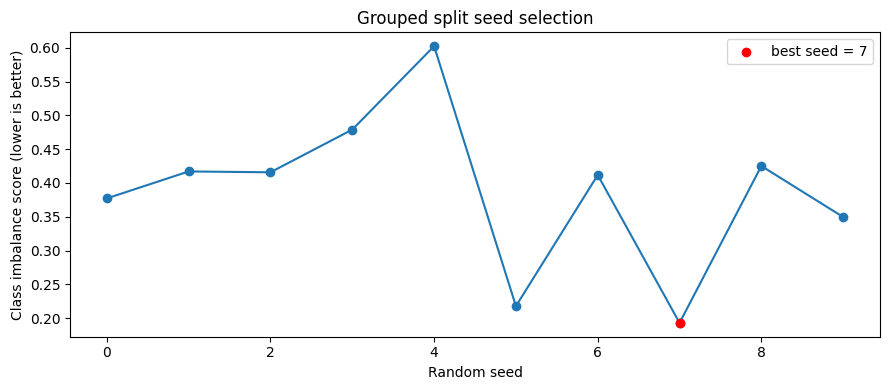

Saved for Medium: /content/drive/MyDrive/ai builders/figures/split_seed_selection.png


In [16]:
def grouped_split_with_seed(source_df, seed):
    """Split source groups without allowing augmented copies to leak across splits."""
    if len(source_df) < N_SPLITS:
        raise ValueError(f'Not enough sources for {N_SPLITS} folds: {len(source_df)}')
    X = source_df['source_id'].values
    y = source_df['dominant_class_id'].values
    groups = source_df['source_id'].values
    sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    folds = list(sgkf.split(X, y, groups))
    test_idx = set(folds[0][1])
    val_idx = set(folds[1][1])
    all_idx = set(range(len(source_df)))
    train_idx = all_idx - test_idx - val_idx
    source_to_split = {}
    for idx in train_idx:
        source_to_split[source_df.iloc[idx]['source_id']] = 'train'
    for idx in val_idx:
        source_to_split[source_df.iloc[idx]['source_id']] = 'val'
    for idx in test_idx:
        source_to_split[source_df.iloc[idx]['source_id']] = 'test'
    return source_to_split

def class_distribution_for_split(df, split_series):
    out = {}
    for split in SPLITS:
        part = df[split_series == split]
        counts = Counter({cls_id: int(part[f'count_{cls_name}_v2'].sum()) for cls_id, cls_name in CLASS_NAMES.items()})
        total = sum(counts.values())
        out[split] = {'counts': {CLASS_NAMES[k]: int(v) for k, v in counts.items()}, 'pct': {k: (counts[k] / total if total else 0.0) for k in CLASS_NAMES}, 'total': int(total)}
    return out

def measure_class_balance(df, split_series):
    dist = class_distribution_for_split(df, split_series)
    score = 0.0
    for cls_id in CLASS_NAMES:
        train_pct = dist['train']['pct'][cls_id]
        score += abs(dist['val']['pct'][cls_id] - train_pct)
        score += abs(dist['test']['pct'][cls_id] - train_pct)
    return float(score), dist

print('Searching for best-balanced grouped split...')
best_seed, best_score, best_source_to_split = None, float('inf'), None
seed_results = []
for seed in SEEDS_TO_TRY:
    source_to_split = grouped_split_with_seed(source_df, seed)
    file_split = manifest['source_id'].map(source_to_split)
    score, _dist = measure_class_balance(manifest, file_split)
    split_counts = file_split.value_counts().to_dict()
    result = {'seed': int(seed), 'imbalance_score': float(score), 'train_files': int(split_counts.get('train', 0)), 'val_files': int(split_counts.get('val', 0)), 'test_files': int(split_counts.get('test', 0))}
    seed_results.append(result)
    print(f"  seed {seed}: imbalance score={score:.4f} files train/val/test={result['train_files']}/{result['val_files']}/{result['test_files']}")
    if score < best_score:
        best_seed, best_score, best_source_to_split = seed, score, source_to_split
manifest['split'] = manifest['source_id'].map(best_source_to_split)
source_df['split'] = source_df['source_id'].map(best_source_to_split)
if manifest['split'].isna().any():
    raise AssertionError('Some files did not receive a grouped split.')
print(f'\nBest seed: {best_seed} (score={best_score:.4f})')
print(manifest['split'].value_counts().reindex(SPLITS).fillna(0).astype(int).to_string())


seed_results_df = pd.DataFrame(seed_results)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(seed_results_df['seed'], seed_results_df['imbalance_score'], marker='o')
ax.scatter([best_seed], [best_score], color='red', zorder=3, label=f'best seed = {best_seed}')
ax.set_title('Grouped split seed selection')
ax.set_xlabel('Random seed')
ax.set_ylabel('Class imbalance score (lower is better)')
ax.legend()
plt.tight_layout()
seed_figure_path = FIG_DIR / 'split_seed_selection.png'
fig.savefig(seed_figure_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved for Medium: {seed_figure_path}')


**คำอธิบายรูป:** เปรียบเทียบ deterministic seeds 10 ค่า แล้วเลือก seed ที่ลด class-distribution drift โดยยังคง zero source leakage


## เช็ก source leakage และ class distribution


Leakage verification
No leakage: every source_id belongs to exactly one split.

Split sizes by files:
split
train    1898
val       201
test      230

Split sizes by unique sources:
split
train    934
val      117
test     117

Class distribution per split (all 6 original classes):
Class                  train%     val%    test%   train_n     val_n    test_n
panel_clean            23.74%   24.92%   21.93%     5,843       669       575
panel_defective        21.88%   21.64%   20.25%     5,385       581       531
dust                   16.40%   15.57%   15.75%     4,036       418       413
bird_drop              20.86%   17.88%   19.34%     5,133       480       507
physical_damage         7.92%    9.31%   11.63%     1,949       250       305
leaf                    9.20%   10.69%   11.10%     2,265       287       291

Balance check:
  no severe under-representation warnings


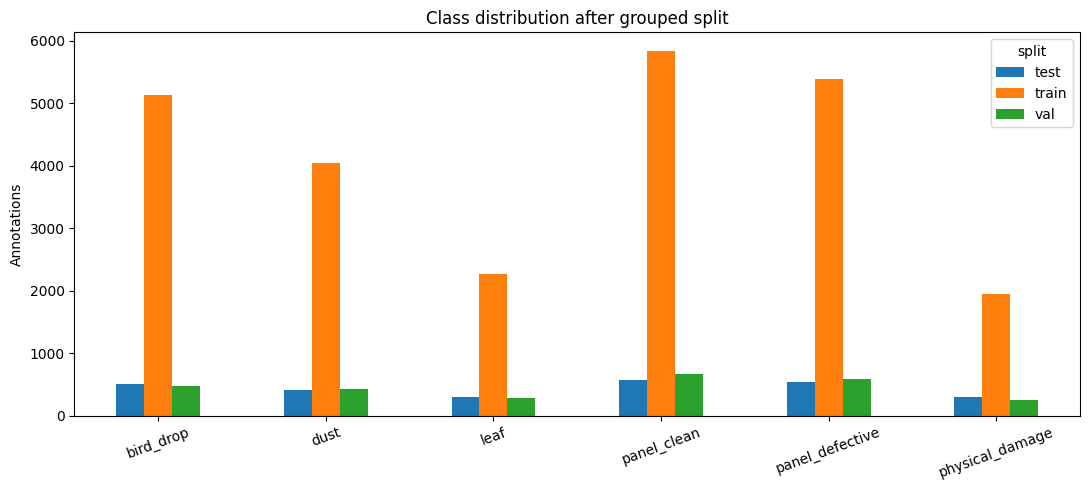

Saved for Medium: /content/drive/MyDrive/ai builders/figures/grouped_split_distribution.png


In [17]:
print('Leakage verification')
source_split_counts = manifest.groupby('source_id')['split'].nunique()
leaked_sources = source_split_counts[source_split_counts > 1]
if len(leaked_sources):
    print(f'LEAKAGE: {len(leaked_sources):,} source IDs span multiple splits')
    display(leaked_sources.head(20))
    raise AssertionError('Grouped split failed: source leakage detected.')
print('No leakage: every source_id belongs to exactly one split.')

print('\nSplit sizes by files:')
print(manifest['split'].value_counts().reindex(SPLITS).fillna(0).astype(int).to_string())
print('\nSplit sizes by unique sources:')
print(source_df['split'].value_counts().reindex(SPLITS).fillna(0).astype(int).to_string())

_, split_class_dist = measure_class_balance(manifest, manifest['split'])
print('\nClass distribution per split (all 6 original classes):')
print(f"{'Class':<20} {'train%':>8} {'val%':>8} {'test%':>8} {'train_n':>9} {'val_n':>9} {'test_n':>9}")
for cls_id, cls_name in CLASS_NAMES.items():
    train_pct = split_class_dist['train']['pct'][cls_id] * 100
    val_pct = split_class_dist['val']['pct'][cls_id] * 100
    test_pct = split_class_dist['test']['pct'][cls_id] * 100
    train_n = split_class_dist['train']['counts'][cls_name]
    val_n = split_class_dist['val']['counts'][cls_name]
    test_n = split_class_dist['test']['counts'][cls_name]
    print(f'{cls_name:<20} {train_pct:>7.2f}% {val_pct:>7.2f}% {test_pct:>7.2f}% {train_n:>9,} {val_n:>9,} {test_n:>9,}')

balance_warnings = []
for split in ['val', 'test']:
    for cls_id, cls_name in CLASS_NAMES.items():
        train_pct = split_class_dist['train']['pct'][cls_id]
        split_pct = split_class_dist[split]['pct'][cls_id]
        if train_pct > 0 and split_pct < train_pct * 0.5:
            balance_warnings.append(f'{cls_name} under-represented in {split}: {split_pct*100:.2f}% vs train {train_pct*100:.2f}%')
print('\nBalance check:')
if balance_warnings:
    for warning in balance_warnings:
        print(f'  warning: {warning}')
else:
    print('  no severe under-representation warnings')


distribution_rows = []
for split in SPLITS:
    for class_id, class_name in CLASS_NAMES.items():
        distribution_rows.append({
            'split': split,
            'class_name': class_name,
            'annotations': split_class_dist[split]['counts'][class_name],
        })
distribution_df = pd.DataFrame(distribution_rows)
distribution_pivot = distribution_df.pivot(
    index='class_name', columns='split', values='annotations'
).fillna(0)

fig, ax = plt.subplots(figsize=(11, 5))
distribution_pivot.plot(kind='bar', ax=ax)
ax.set_title('Class distribution after grouped split')
ax.set_ylabel('Annotations')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
distribution_figure_path = FIG_DIR / 'grouped_split_distribution.png'
fig.savefig(distribution_figure_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved for Medium: {distribution_figure_path}')


**คำอธิบายรูป:** grouped train/validation/test split ยังมีครบทุก class และเก็บ Roboflow augmentations จาก source เดียวกันไว้ใน split เดียว


## แยก panel dataset กับ defect dataset

`dataset_panel` เก็บเฉพาะภาพที่มี panel mask ส่วน `dataset_defect` เก็บภาพที่มี defect mask ตามเดิมใน train/val และเก็บ test ครบ 230 ภาพ ภาพสะอาด 31 ภาพจึงมี empty label

การ export จะเขียนลง staging folders ก่อน และเปลี่ยนมาใช้เป็น folder จริงเมื่อจำนวน images/labels ครบและผ่าน validation แล้วเท่านั้น ถ้า Colab หยุดกลางทาง dataset เดิมจะไม่ถูกลบ


In [18]:
PANEL_STAGING = DRIVE_BASE / 'dataset_panel_building'
DEFECT_STAGING = DRIVE_BASE / 'dataset_defect_building'


def write_data_yaml(output_dir, dataset_path, names, description):
    data_yaml = {
        'path': str(dataset_path),
        'train': 'images/train',
        'val': 'images/val',
        'test': 'images/test',
        'nc': len(names),
        'names': names,
    }
    path = output_dir / 'data.yaml'
    with open(path, 'w', encoding='utf-8') as handle:
        yaml.safe_dump(
            data_yaml,
            handle,
            sort_keys=False,
            allow_unicode=True,
        )
    print(f'{description} data.yaml prepared: {path}')
    return path


def recover_interrupted_publish(output_dir):
    backup_dir = output_dir.with_name(f'{output_dir.name}_backup')
    if not output_dir.exists() and backup_dir.exists():
        shutil.move(str(backup_dir), str(output_dir))
        print(f'Restored interrupted export backup: {output_dir}')


def prepare_staging_dataset(path):
    path = Path(path)
    if path.exists():
        shutil.rmtree(path)
    for split in SPLITS:
        (path / 'images' / split).mkdir(parents=True, exist_ok=True)
        (path / 'labels' / split).mkdir(parents=True, exist_ok=True)


def write_yolo_label_filtered(polygons, output_path, keep_classes, class_remap):
    lines = []
    for cls_id, coords in polygons:
        if cls_id not in keep_classes:
            continue
        coord_text = ' '.join(f'{float(coord):.6f}' for coord in coords)
        lines.append(f'{int(class_remap[cls_id])} {coord_text}')
    output_path.write_text(
        '\n'.join(lines) + ('\n' if lines else ''),
        encoding='utf-8',
    )
    return len(lines)


def build_filtered_dataset(
    staging_dir,
    keep_classes,
    class_remap,
    dataset_name,
    empty_label_splits=(),
):
    empty_label_splits = set(empty_label_splits)
    stats = {
        split: {
            'images': 0,
            'labels': 0,
            'instances': 0,
            'empty_labels': 0,
            'skipped_no_target': 0,
            'missing_source': 0,
        }
        for split in SPLITS
    }
    exported_rows = []

    for split in SPLITS:
        img_out = staging_dir / 'images' / split
        lbl_out = staging_dir / 'labels' / split
        split_rows = manifest[manifest['split'] == split]

        for row in tqdm(
            split_rows.itertuples(index=False),
            total=len(split_rows),
            desc=f'{dataset_name}/{split}',
        ):
            filename = row.filename
            polygons = polygons_by_filename.get(filename, [])
            target_polygons = [
                (cls_id, coords)
                for cls_id, coords in polygons
                if cls_id in keep_classes
            ]
            keep_empty_label = split in empty_label_splits
            if not target_polygons and not keep_empty_label:
                stats[split]['skipped_no_target'] += 1
                continue

            src_img = image_index.get(filename)
            if src_img is None or not src_img.exists():
                stats[split]['missing_source'] += 1
                continue

            dst_img = img_out / filename
            dst_lbl = lbl_out / f'{Path(filename).stem}.txt'
            n_lines = write_yolo_label_filtered(
                target_polygons,
                dst_lbl,
                keep_classes,
                class_remap,
            )
            shutil.copy2(src_img, dst_img)

            is_empty_label = n_lines == 0
            stats[split]['images'] += 1
            stats[split]['labels'] += 1
            stats[split]['instances'] += int(n_lines)
            stats[split]['empty_labels'] += int(is_empty_label)
            exported_rows.append({
                'filename': filename,
                'source_id': row.source_id,
                'split': split,
                'category': row.category,
                'instances': int(n_lines),
                'is_empty_label': bool(is_empty_label),
            })

    manifest_out = pd.DataFrame(exported_rows)
    manifest_out.to_csv(staging_dir / 'manifest.csv', index=False)
    return stats, manifest_out


def expected_export_counts(keep_classes, empty_label_splits=()):
    empty_label_splits = set(empty_label_splits)
    expected = {}
    for split in SPLITS:
        split_df = manifest[manifest['split'] == split]
        if split in empty_label_splits:
            expected[split] = len(split_df)
            continue
        class_columns = [
            f'count_{CLASS_NAMES[class_id]}_v2'
            for class_id in keep_classes
        ]
        expected[split] = int((split_df[class_columns].sum(axis=1) > 0).sum())
    return expected


def verify_staging_dataset(staging_dir, stats, expected_counts, dataset_name):
    errors = []
    for split in SPLITS:
        image_dir = staging_dir / 'images' / split
        label_dir = staging_dir / 'labels' / split
        image_stems = {path.stem for path in image_dir.glob('*.jpg')}
        label_stems = {path.stem for path in label_dir.glob('*.txt')}
        expected = int(expected_counts[split])

        if image_stems != label_stems:
            errors.append(f'{dataset_name}/{split}: image-label stems differ')
        if len(image_stems) != expected:
            errors.append(
                f'{dataset_name}/{split}: expected {expected:,} files, '
                f'got {len(image_stems):,}'
            )
        if stats[split]['missing_source']:
            errors.append(
                f'{dataset_name}/{split}: '
                f'{stats[split]["missing_source"]:,} source images missing'
            )

    if errors:
        raise RuntimeError(
            f'{dataset_name} staging validation failed. '
            'The existing dataset was not changed:\n- '
            + '\n- '.join(errors)
        )


def publish_staging_dataset(staging_dir, output_dir):
    backup_dir = output_dir.with_name(f'{output_dir.name}_backup')
    if backup_dir.exists():
        shutil.rmtree(backup_dir)

    if output_dir.exists():
        shutil.move(str(output_dir), str(backup_dir))

    try:
        shutil.move(str(staging_dir), str(output_dir))
    except Exception:
        if output_dir.exists():
            shutil.rmtree(output_dir)
        if backup_dir.exists():
            shutil.move(str(backup_dir), str(output_dir))
        raise

    if backup_dir.exists():
        shutil.rmtree(backup_dir)


recover_interrupted_publish(OUTPUT_PANEL)
recover_interrupted_publish(OUTPUT_DEFECT)
prepare_staging_dataset(PANEL_STAGING)
prepare_staging_dataset(DEFECT_STAGING)

panel_stats, panel_manifest = build_filtered_dataset(
    PANEL_STAGING,
    PANEL_KEEP,
    PANEL_REMAP,
    'panel',
)
defect_stats, defect_manifest = build_filtered_dataset(
    DEFECT_STAGING,
    DEFECT_KEEP,
    DEFECT_REMAP,
    'defect',
    empty_label_splits={'test'},
)

panel_expected = expected_export_counts(PANEL_KEEP)
defect_expected = expected_export_counts(
    DEFECT_KEEP,
    empty_label_splits={'test'},
)
verify_staging_dataset(
    PANEL_STAGING,
    panel_stats,
    panel_expected,
    'panel',
)
verify_staging_dataset(
    DEFECT_STAGING,
    defect_stats,
    defect_expected,
    'defect',
)

write_data_yaml(
    PANEL_STAGING,
    OUTPUT_PANEL,
    PANEL_NAMES,
    'Panel dataset',
)
write_data_yaml(
    DEFECT_STAGING,
    OUTPUT_DEFECT,
    DEFECT_NAMES,
    'Defect dataset',
)

publish_staging_dataset(PANEL_STAGING, OUTPUT_PANEL)
publish_staging_dataset(DEFECT_STAGING, OUTPUT_DEFECT)

panel_yaml_path = OUTPUT_PANEL / 'data.yaml'
defect_yaml_path = OUTPUT_DEFECT / 'data.yaml'

print('Panel export stats:')
print(pd.DataFrame(panel_stats).T)
print('\nDefect export stats:')
print(pd.DataFrame(defect_stats).T)
print(f'Published panel dataset:  {OUTPUT_PANEL}')
print(f'Published defect dataset: {OUTPUT_DEFECT}')


panel/train:   0%|          | 0/1898 [00:00<?, ?it/s]

panel/val:   0%|          | 0/201 [00:00<?, ?it/s]

panel/test:   0%|          | 0/230 [00:00<?, ?it/s]

defect/train:   0%|          | 0/1898 [00:00<?, ?it/s]

defect/val:   0%|          | 0/201 [00:00<?, ?it/s]

defect/test:   0%|          | 0/230 [00:00<?, ?it/s]

Panel dataset data.yaml prepared: /content/drive/MyDrive/ai builders/dataset/dataset_panel_building/data.yaml
Defect dataset data.yaml prepared: /content/drive/MyDrive/ai builders/dataset/dataset_defect_building/data.yaml
Panel export stats:
       images  labels  instances  empty_labels  skipped_no_target  \
train    1898    1898      11228             0                  0   
val       201     201       1250             0                  0   
test      230     230       1106             0                  0   

       missing_source  
train               0  
val                 0  
test                0  

Defect export stats:
       images  labels  instances  empty_labels  skipped_no_target  \
train    1609    1609      13383             0                289   
val       176     176       1435             0                 25   
test      230     230       1516            31                  0   

       missing_source  
train               0  
val                 0  
test          

## เขียน data.yaml ของทั้งสอง dataset


In [19]:
dataset_configs = [
    ('panel', OUTPUT_PANEL, PANEL_NAMES, panel_expected),
    ('defect', OUTPUT_DEFECT, DEFECT_NAMES, defect_expected),
]
data_yaml_paths = {}

for dataset_name, output_dir, class_names, expected_counts in dataset_configs:
    actual_counts = {}
    for split in SPLITS:
        image_dir = output_dir / 'images' / split
        label_dir = output_dir / 'labels' / split
        images = sorted(image_dir.glob('*.jpg'))
        labels = sorted(label_dir.glob('*.txt'))
        actual_counts[split] = len(images)

        if len(images) != int(expected_counts[split]):
            raise RuntimeError(
                f'{dataset_name}/{split} is incomplete: '
                f'expected {int(expected_counts[split]):,} images, '
                f'found {len(images):,}'
            )
        if {path.stem for path in images} != {path.stem for path in labels}:
            raise RuntimeError(
                f'{dataset_name}/{split} image-label stems do not match.'
            )

    data_yaml = {
        'path': str(output_dir),
        'train': 'images/train',
        'val': 'images/val',
        'test': 'images/test',
        'nc': len(class_names),
        'names': class_names,
    }
    data_yaml_path = output_dir / 'data.yaml'
    with open(data_yaml_path, 'w', encoding='utf-8') as handle:
        yaml.safe_dump(
            data_yaml,
            handle,
            sort_keys=False,
            allow_unicode=True,
        )

    with open(data_yaml_path, 'r', encoding='utf-8') as handle:
        saved_config = yaml.safe_load(handle)
    if saved_config != data_yaml:
        raise IOError(f'Could not verify saved config: {data_yaml_path}')

    data_yaml_paths[dataset_name] = data_yaml_path
    print(f'{dataset_name} counts: {actual_counts}')
    print(f'{dataset_name} config: {data_yaml_path}')

panel_yaml_path = data_yaml_paths['panel']
defect_yaml_path = data_yaml_paths['defect']


panel counts: {'train': 1898, 'val': 201, 'test': 230}
panel config: /content/drive/MyDrive/ai builders/dataset/dataset_panel/data.yaml
defect counts: {'train': 1609, 'val': 176, 'test': 230}
defect config: /content/drive/MyDrive/ai builders/dataset/dataset_defect/data.yaml


## ตรวจ labels หลัง remap class

Empty label ยอมรับได้เฉพาะ `dataset_defect/test` เพราะเป็น clean negative สำหรับการวัด false positives ส่วน split และ dataset อื่นยังต้องมี polygon อย่างน้อยหนึ่ง instance


In [20]:
def validate_label_file(path, allowed_classes, allow_empty=False):
    errors = []
    text = path.read_text(encoding='utf-8').strip()
    if not text:
        if not allow_empty:
            errors.append(f'{path}: empty label file')
        return errors

    for line_no, line in enumerate(text.splitlines(), start=1):
        parts = line.split()
        if len(parts) < 7:
            errors.append(f'{path}:{line_no}: too few values')
            continue
        try:
            cls_id = int(float(parts[0]))
            coords = [float(x) for x in parts[1:]]
        except ValueError:
            errors.append(f'{path}:{line_no}: parse error')
            continue
        if cls_id not in allowed_classes:
            errors.append(
                f'{path}:{line_no}: invalid class id {cls_id}; '
                f'allowed={sorted(allowed_classes)}'
            )
        if len(coords) < 6 or len(coords) % 2 != 0:
            errors.append(
                f'{path}:{line_no}: invalid coordinate count {len(coords)}'
            )
        if any((not math.isfinite(c)) or c < 0 or c > 1 for c in coords):
            errors.append(f'{path}:{line_no}: coordinate outside [0,1]')
    return errors


def validate_dataset(
    output_dir,
    allowed_classes,
    dataset_manifest,
    dataset_name,
    empty_label_splits=(),
):
    empty_label_splits = set(empty_label_splits)
    errors, counts = [], {}

    for split in SPLITS:
        img_dir = output_dir / 'images' / split
        lbl_dir = output_dir / 'labels' / split
        imgs = sorted(img_dir.glob('*.jpg'))
        lbls = sorted(lbl_dir.glob('*.txt'))
        img_stems = {path.stem for path in imgs}
        lbl_stems = {path.stem for path in lbls}

        if img_stems - lbl_stems:
            errors.append(
                f'{dataset_name}/{split}: '
                f'{len(img_stems - lbl_stems):,} images without labels'
            )
        if lbl_stems - img_stems:
            errors.append(
                f'{dataset_name}/{split}: '
                f'{len(lbl_stems - img_stems):,} labels without images'
            )

        empty_labels = [
            path for path in lbls
            if not path.read_text(encoding='utf-8').strip()
        ]
        allow_empty = split in empty_label_splits
        for lbl in lbls:
            errors.extend(
                validate_label_file(
                    lbl,
                    allowed_classes,
                    allow_empty=allow_empty,
                )
            )

        manifest_split = dataset_manifest[dataset_manifest['split'] == split]
        expected = len(manifest_split)
        expected_empty = (
            int(manifest_split['is_empty_label'].sum())
            if 'is_empty_label' in manifest_split
            else 0
        )
        if len(imgs) != expected or len(lbls) != expected:
            errors.append(
                f'{dataset_name}/{split}: expected {expected:,}, '
                f'got {len(imgs):,} images and {len(lbls):,} labels'
            )
        if len(empty_labels) != expected_empty:
            errors.append(
                f'{dataset_name}/{split}: expected {expected_empty:,} empty labels, '
                f'got {len(empty_labels):,}'
            )

        counts[split] = {
            'images': len(imgs),
            'labels': len(lbls),
            'empty_labels': len(empty_labels),
            'expected': int(expected),
        }

    if not dataset_manifest.empty:
        leaked = dataset_manifest.groupby('source_id')['split'].nunique()
        leaked = leaked[leaked > 1]
        if len(leaked):
            errors.append(
                f'{dataset_name}: {len(leaked):,} source IDs leak across splits'
            )

    print(f'{dataset_name} validation counts:')
    print(pd.DataFrame(counts).T)
    if errors:
        for error in errors[:50]:
            print(f'  - {error}')
        raise ValueError(f'{dataset_name} validation failed')
    print(f'{dataset_name} validation passed.')
    return counts


panel_validation = validate_dataset(
    OUTPUT_PANEL,
    {0},
    panel_manifest,
    'dataset_panel',
)
defect_validation = validate_dataset(
    OUTPUT_DEFECT,
    {0, 1, 2, 3},
    defect_manifest,
    'dataset_defect',
    empty_label_splits={'test'},
)

expected_defect_test_images = int((manifest['split'] == 'test').sum())
if defect_validation['test']['images'] != expected_defect_test_images:
    raise AssertionError(
        'dataset_defect/test must include every image from the grouped test split: '
        f'expected {expected_defect_test_images:,}, '
        f'got {defect_validation["test"]["images"]:,}'
    )


dataset_panel validation counts:
       images  labels  empty_labels  expected
train    1898    1898             0      1898
val       201     201             0       201
test      230     230             0       230
dataset_panel validation passed.
dataset_defect validation counts:
       images  labels  empty_labels  expected
train    1609    1609             0      1609
val       176     176             0       176
test      230     230            31       230
dataset_defect validation passed.


## บันทึก split และจำนวนข้อมูล


In [21]:
def dataset_class_dist(output_dir, n_classes, names_map):
    dist = {}
    for split in SPLITS:
        counts = Counter()
        for lbl in (output_dir / 'labels' / split).glob('*.txt'):
            for line in lbl.read_text(encoding='utf-8').splitlines():
                if line.strip():
                    counts[int(float(line.split()[0]))] += 1
        dist[split] = {names_map[c]: int(counts.get(c, 0)) for c in range(n_classes)}
    return dist

split_manifest = manifest.copy()
split_manifest.to_csv(SPLIT_MANIFEST_PATH, index=False)
panel_dist = dataset_class_dist(OUTPUT_PANEL, 1, PANEL_NAMES)
defect_dist = dataset_class_dist(OUTPUT_DEFECT, 4, DEFECT_NAMES)

summary = {
    'phase': 'grouped split preparation - Grouped split + two-stage datasets',
    'created_at': datetime.now(timezone.utc).isoformat(),
    'input_dataset': str(REVIEWED_DATASET),
    'split_method': 'StratifiedGroupKFold by source_id',
    'source_id_rule': 'filename.split(".rf.")[0], fallback Path(filename).stem',
    'n_splits': int(N_SPLITS),
    'seeds_tried': seed_results,
    'best_seed': int(best_seed),
    'best_imbalance_score': float(best_score),
    'leakage_check': 'passed',
    'balance_warnings': balance_warnings,
    'unique_sources': int(n_sources),
    'total_files': int(n_files),
    'augmentation_ratio': float(aug_ratio),
    'split_sizes_files': {str(k): int(v) for k, v in manifest['split'].value_counts().reindex(SPLITS).fillna(0).astype(int).to_dict().items()},
    'split_sizes_sources': {str(k): int(v) for k, v in source_df['split'].value_counts().reindex(SPLITS).fillna(0).astype(int).to_dict().items()},
    'class_distribution_original_six_classes': split_class_dist,
    'dataset_panel': {'path': str(OUTPUT_PANEL), 'names': PANEL_NAMES, 'export_stats': panel_stats, 'validation': panel_validation, 'class_distribution': panel_dist},
    'dataset_defect': {'path': str(OUTPUT_DEFECT), 'names': DEFECT_NAMES, 'export_stats': defect_stats, 'validation': defect_validation, 'class_distribution': defect_dist},
    'outputs': {'split_manifest_v2': str(SPLIT_MANIFEST_PATH), 'phase4v2_summary': str(SUMMARY_PATH), 'dataset_panel_data_yaml': str(panel_yaml_path), 'dataset_defect_data_yaml': str(defect_yaml_path)},
}
with open(SUMMARY_PATH, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f'Saved split manifest: {SPLIT_MANIFEST_PATH}')
print(f'Saved summary: {SUMMARY_PATH}')

split_counts = manifest['split'].value_counts().reindex(SPLITS).fillna(0).astype(int)
source_counts = source_df['split'].value_counts().reindex(SPLITS).fillna(0).astype(int)

print("Grouped split summary")
print(f"  Seed: {best_seed}")
print("  Source leakage: none")
print(f"  Sources: {n_sources:,}")
print(f"  Files: {n_files:,}")
print(f"  Augmentation ratio: {aug_ratio:.2f}x")
print(
    "  Split files: "
    f"train={split_counts.get('train', 0):,}, "
    f"val={split_counts.get('val', 0):,}, "
    f"test={split_counts.get('test', 0):,}"
)
print(
    "  Split sources: "
    f"train={source_counts.get('train', 0):,}, "
    f"val={source_counts.get('val', 0):,}, "
    f"test={source_counts.get('test', 0):,}"
)
print(f"  Panel dataset: {OUTPUT_PANEL}")
print(f"  Defect dataset: {OUTPUT_DEFECT}")


Saved split manifest: /content/drive/MyDrive/ai builders/dataset/split_manifest_v2.csv
Saved summary: /content/drive/MyDrive/ai builders/dataset/phase4v2_summary.json
Grouped split summary
  Seed: 7
  Source leakage: none
  Sources: 1,168
  Files: 2,329
  Augmentation ratio: 1.99x
  Split files: train=1,898, val=201, test=230
  Split sources: train=934, val=117, test=117
  Panel dataset: /content/drive/MyDrive/ai builders/dataset/dataset_panel
  Defect dataset: /content/drive/MyDrive/ai builders/dataset/dataset_defect


## สรุป

Grouped split มี train 1,898 ภาพ, validation 201 ภาพ และ test 230 ภาพ โดยไม่มี `source_id` รั่วข้าม split
